# Imports

In [1]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Varying transform

## load data

In [21]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

baselines = pd.read_csv(f'{save_root}/baselines_params.csv')
finetunes_best = pd.read_csv(f'{save_root}/best_finetune_each_params.csv')

base = baselines.copy()
base = base[
    ((base.data_id == 'ECL') & (base.model == 'iTransformer')) |
    ((base.data_id == 'Weather') & (base.model == 'FreTS'))
]

best = finetunes_best.copy()
best = best[
    ((best.data_id == 'ECL_PCA') & (best.model == 'iTransformer')) |
    ((best.data_id == 'Weather_PCA') & (best.model == 'FreTS'))
]

root = '/data/home/Licheng/workspace/TSF-PCA/results_PCA/diff_trans'
exp_dirs = os.listdir(root)
exp_dirs = [os.path.join(root, exp_dir) for exp_dir in exp_dirs]

params = ['model', 'seq_len', 'pred_len', 'data_id', 'learning_rate', 'rec_lambda', 'auxi_lambda', 'pca_dim', 'reinit', 'use_weights', 'rank_ratio', 'auxi_loss', 'batch_size', 'auxi_type', 'auxi_mode', 'lradj', 'patience', 'train_epochs']
metric_names = ['mse', 'mae']

df = []
for exp_dir in exp_dirs:
    runned, setting_dir = exist_metric(exp_dir)
    if not runned:
        continue

    config = load_yaml_as_df(os.path.join(setting_dir, 'config.yaml'))
    metric = load_npy(os.path.join(setting_dir, 'metrics.npy'))
    result = config[params]
    result.loc[:, metric_names] = metric[1], metric[0]
    result.loc[:, ['exp_dir']] = exp_dir
    df.append(result)

df = pd.concat(df, ignore_index=True)
df.sort_values(by=['model', 'data_id', 'pred_len'], inplace=True)
df.head(4)

,model,seq_len,pred_len,data_id,learning_rate,rec_lambda,auxi_lambda,pca_dim,reinit,use_weights,rank_ratio,auxi_loss,batch_size,auxi_type,auxi_mode,lradj,patience,train_epochs,mse,mae,exp_dir
65,FreTS,96,96,Weather_FA,0.001,0.2,0.8,T,1,0,1.0,MAE,32,fa,basis,type1,3,10,0.171692,0.224669,/data/home/Licheng/workspace/TSF-PCA/results_P...
259,FreTS,96,192,Weather_FA,0.001,0.2,0.8,T,1,0,1.0,MAE,32,fa,basis,type1,3,10,0.212493,0.263629,/data/home/Licheng/workspace/TSF-PCA/results_P...
325,FreTS,96,336,Weather_FA,0.001,0.2,0.8,T,1,0,1.0,MAE,32,fa,basis,type1,3,10,0.261259,0.299690,/data/home/Licheng/workspace/TSF-PCA/results_P...
75,FreTS,96,720,Weather_FA,0.001,0.2,0.8,T,1,0,1.0,MAE,32,fa,basis,type1,3,10,0.335380,0.360984,/data/home/Licheng/workspace/TSF-PCA/results_P...


## preprocess

In [23]:
df2 = df.copy()
df2.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'auxi_type'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2 = df2[best.columns]

df3 = pd.concat([best, df2], ignore_index=True)

df3 = df3[df3.auxi_type.isin(['pca', 'fa', 'robustpca', 'svd'])]
df3['data_id'] = df3['data_id'].apply(lambda x: x.split('_')[0])
df3['auxi_type'] = df3['auxi_type'].replace({'pca': 'PCA', 'fa': 'FA', 'robustpca': 'RPCA', 'svd': 'SVD'})

base['auxi_type'] = 'DF'

columns = ['model', 'data_id', 'pred_len', 'mse', 'mae', 'auxi_type']
df3 = pd.concat([df3[columns], base[columns]], ignore_index=True)
df3['pred_len'] = df3['pred_len'].astype(int)

dst_order = ['ECL', 'Weather']
df3['data_id'] = pd.Categorical(df3['data_id'], categories=dst_order, ordered=True)

model_order = ['iTransformer', 'FreTS']
df3['model'] = pd.Categorical(df3['model'], categories=model_order, ordered=True)

trans_order = ['DF', 'PCA', 'RPCA', 'SVD', 'FA']
df3['auxi_type'] = pd.Categorical(df3['auxi_type'], categories=trans_order, ordered=True)

df3.sort_values(by=['model', 'data_id', 'auxi_type', 'pred_len'], inplace=True)

df4 = df3.copy()
df4 = df4[['auxi_type', 'data_id', 'pred_len', 'mse', 'mae']]
df4_avg = df4.groupby(['auxi_type', 'data_id']).mean(numeric_only=True).reset_index()
df4_avg['pred_len'] = 'Avg'
df4 = pd.concat([df4, df4_avg]).reset_index(drop=True)

df4 = df4.set_index(['data_id', 'pred_len', 'auxi_type']).unstack('auxi_type').swaplevel(axis=1)
columns = []
for auxi_type in df4.columns.levels[0]:
    columns.append((auxi_type, 'mse'))
    columns.append((auxi_type, 'mae'))
df4 = df4[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
df4.round(4).to_csv(f'{save_root}/varying_transform.csv', float_format='%.4f')


df4_avg_show = df4_avg.copy()[['data_id', 'auxi_type', 'mse', 'mae']]
df4_avg_show['df_mse'] = df4_avg_show.groupby('data_id')['mse'].transform(lambda x: x[df4_avg_show.loc[x.index, 'auxi_type'] == 'DF'].values[0])
df4_avg_show['RI_mse'] = (df4_avg_show['df_mse'] - df4_avg_show['mse']) / df4_avg_show['df_mse'] * 100
df4_avg_show['df_mae'] = df4_avg_show.groupby('data_id')['mae'].transform(lambda x: x[df4_avg_show.loc[x.index, 'auxi_type'] == 'DF'].values[0])
df4_avg_show['RI_mae'] = (df4_avg_show['df_mae'] - df4_avg_show['mae']) / df4_avg_show['df_mae'] * 100
df4_avg_show = df4_avg_show[['data_id', 'auxi_type', 'mse', 'RI_mse', 'mae', 'RI_mae']]

df4_avg_show['mse'] = df4_avg_show['mse'].apply(lambda x: f'{x:.3f}')
df4_avg_show['mae'] = df4_avg_show['mae'].apply(lambda x: f'{x:.3f}')
df4_avg_show['RI_mse'] = df4_avg_show['RI_mse'].apply(lambda x: f'{x:.2f}%')
df4_avg_show['RI_mae'] = df4_avg_show['RI_mae'].apply(lambda x: f'{x:.2f}%')

df4_avg_show = df4_avg_show.set_index(['auxi_type', 'data_id']).unstack('data_id').swaplevel(axis=1)
columns = []
for data_id in df4_avg_show.columns.levels[0]:
    columns.append((data_id, 'mse'))
    columns.append((data_id, 'RI_mse'))
    columns.append((data_id, 'mae'))
    columns.append((data_id, 'RI_mae'))
df4_avg_show = df4_avg_show[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
df4_avg_show.to_csv(f'{save_root}/varying_transform_avg.csv')


df4_avg_show

/tmp/ipykernel_1661691/2494547686.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df4_avg = df4.groupby(['auxi_type', 'data_id']).mean(numeric_only=True).reset_index()
/tmp/ipykernel_1661691/2494547686.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df4_avg_show['df_mse'] = df4_avg_show.groupby('data_id')['mse'].transform(lambda x: x[df4_avg_show.loc[x.index, 'auxi_type'] == 'DF'].values[0])
/tmp/ipykernel_1661691/2494547686.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

data_id      ECL                      Weather                     
             mse RI_mse    mae RI_mae     mse RI_mse    mae RI_mae
auxi_type                                                         
DF         0.179  0.00%  0.270  0.00%   0.249  0.00%  0.293  0.00%
PCA        0.170  4.86%  0.260  3.57%   0.241  2.94%  0.280  4.28%
RPCA       0.171  4.31%  0.261  3.16%   0.244  1.78%  0.286  2.38%
SVD        0.175  2.24%  0.264  2.18%   0.248  0.34%  0.290  0.93%
FA         0.175  2.35%  0.265  1.82%   0.245  1.35%  0.287  1.97%

## plot

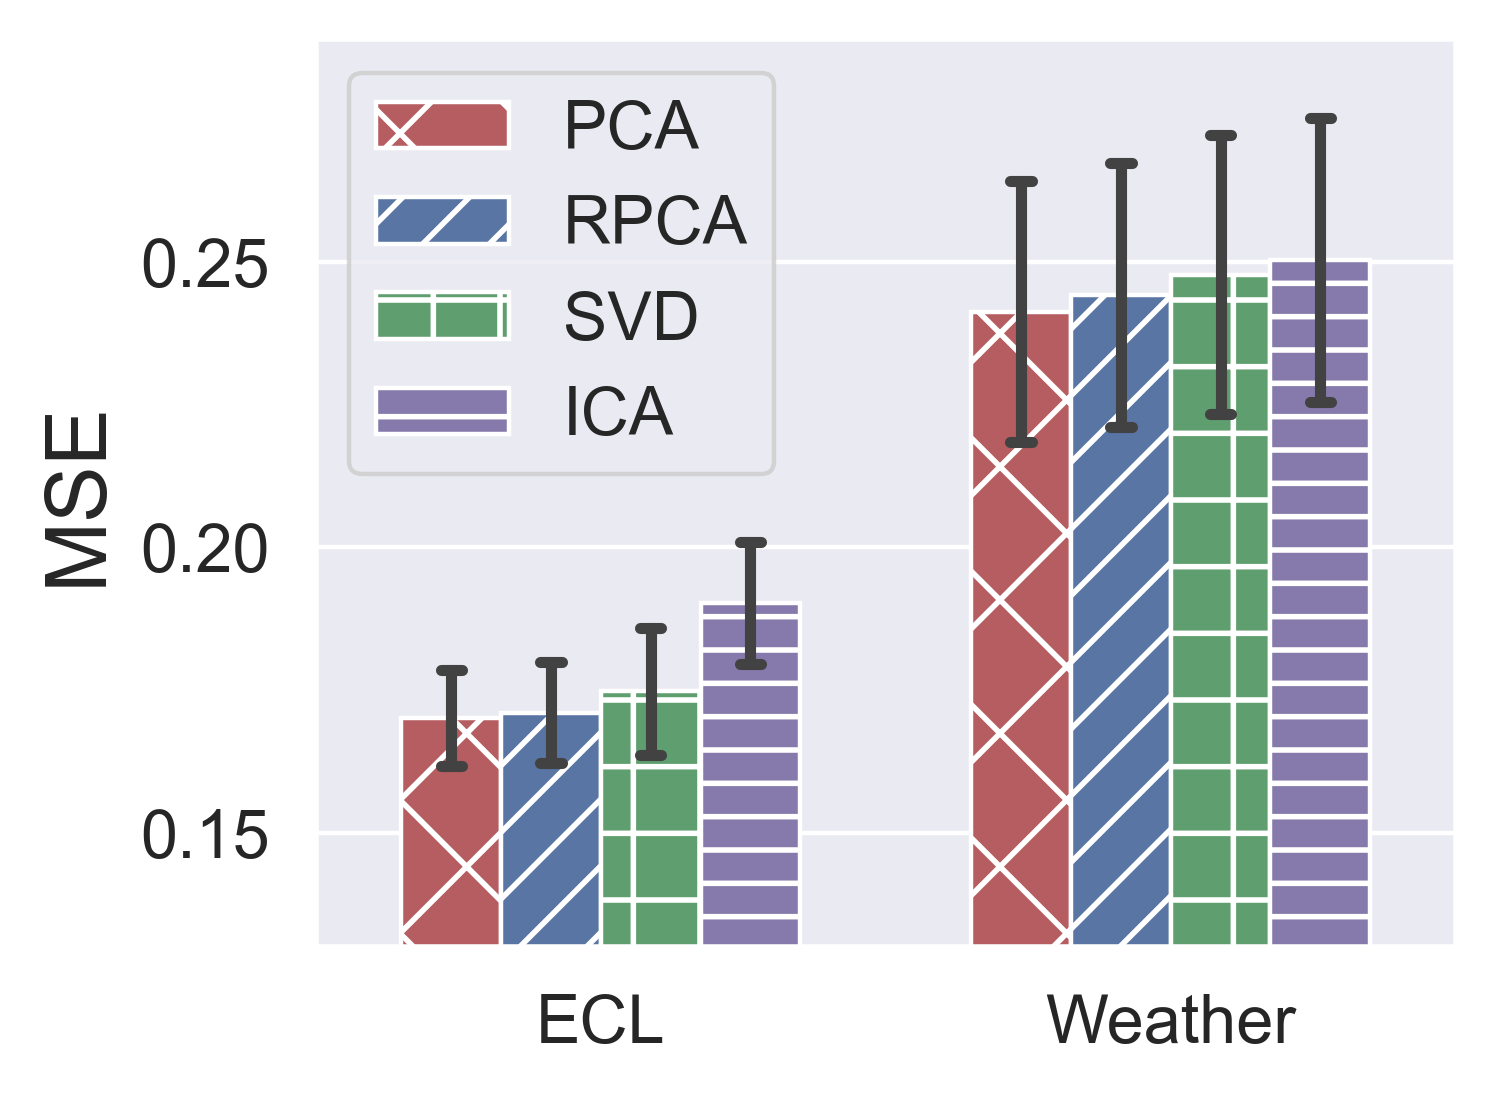

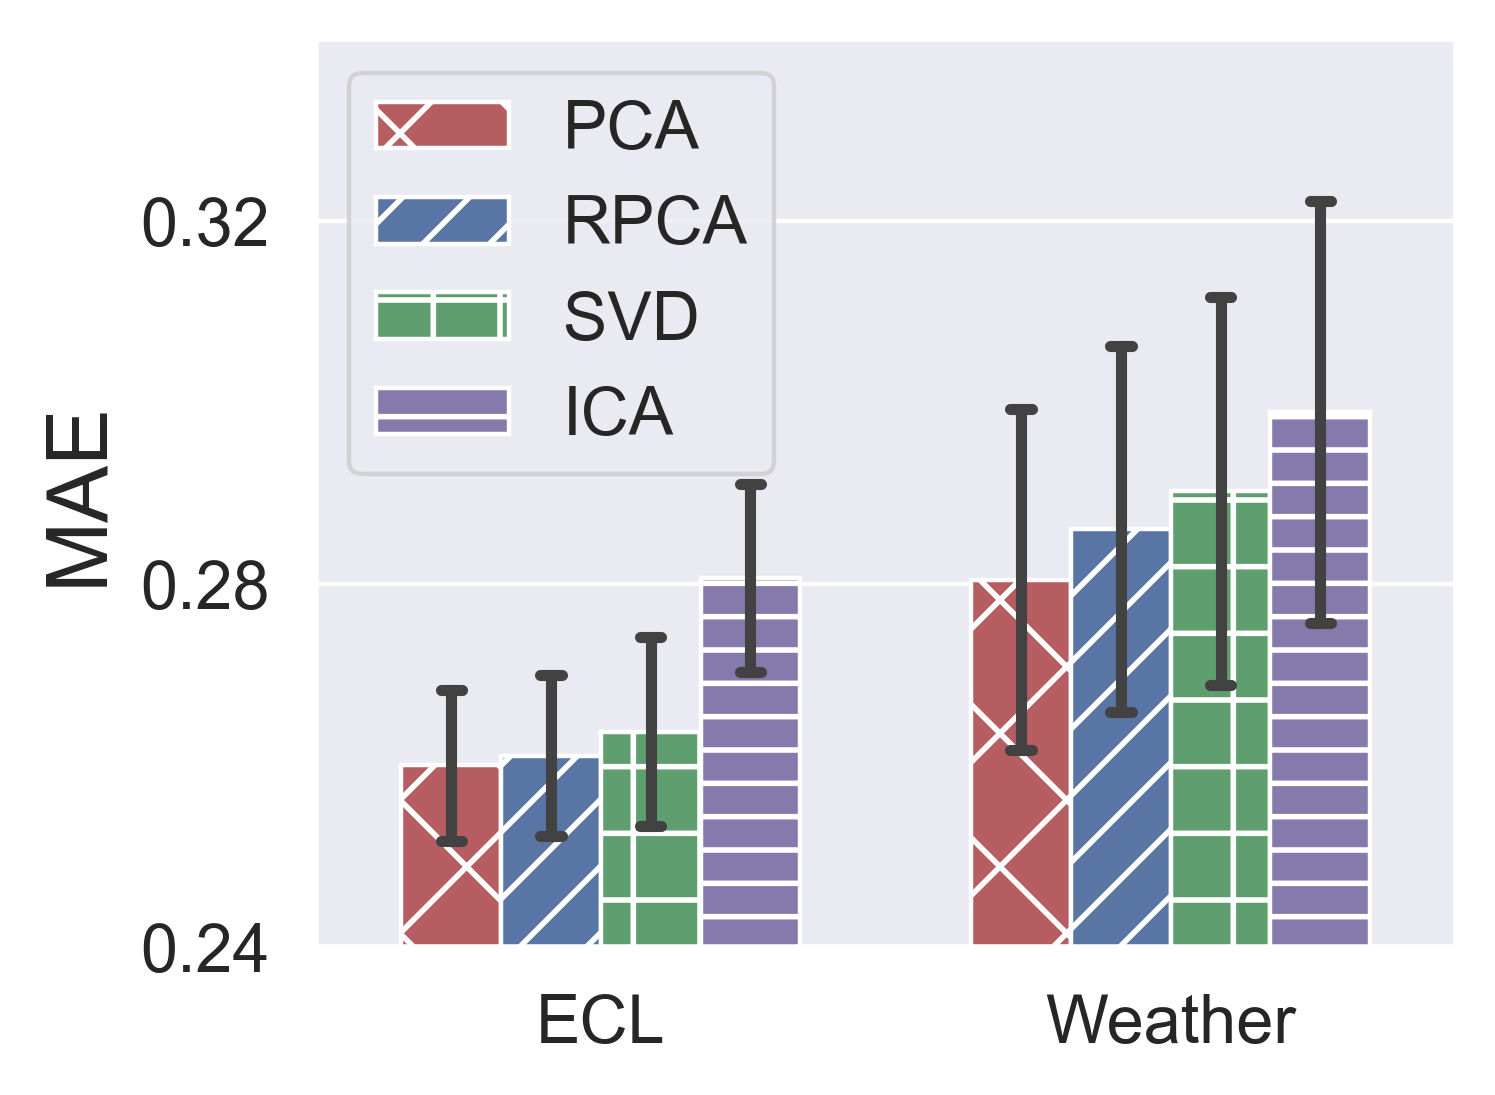

In [78]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper left'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    width = 0.7
    base = 1
    hatchs = ['x', '//', '+', '--']
    ci = 50
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mse', hue='auxi_type', data=df, palette=palette[:4], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*2, (j+1)*2)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,12), hatchs)]

    ax = plt.gca()
    plt.legend(fontsize=12, ncols=1, loc=legend_location)
    plt.xlabel('')
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize)
    if base != 1:
        plt.yscale('log', base=base)
    if ylim1:
        plt.ylim(ylim1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MSE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


    f = plt.figure(dpi=400, figsize=(4, 3))
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mae', hue='auxi_type', data=df, palette=palette[:4], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*2, (j+1)*2)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,12), hatchs)]

    ax = plt.gca()
    # ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    plt.legend(fontsize=12, ncols=1, loc=legend_location)
    plt.ylabel('MAE')
    if base != 1:
        plt.yscale('log', base=base)
    plt.xlabel('')
    plt.tick_params(labelsize=labelsize)
    if ylim2:
        plt.ylim(ylim2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MAE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


dfp = df3.copy()

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/diff_trans'
os.makedirs(save_dir, exist_ok=True)

plot(dfp, save_dir=save_dir, x='data_id', figure_name=f'diff_trans', ylim1=[0.13, None], ylim2=[0.24, 0.34], ypad1=0.05, ypad2=0.04)